In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

X = np.array([0.5, 2.3, 2.9])
y = np.array([1.4, 1.9, 3.2])

In [8]:
def ols_linear_regression(X, y):

    # Calculate mean of X and y
    x_mean = np.mean(X)
    y_mean = np.mean(y)

    # Calculate numerator and denominator
    numerator = np.sum((X - x_mean) * (y - y_mean))
    denominator = np.sum((X - x_mean) ** 2)

    # Calculate slope
    m = numerator / denominator

    # Calculate intercept
    c = y_mean - m * x_mean

    return m, c

In [4]:
def gradient_descent(X, y, alpha=0.05, epochs=1000):

    m = 0.0
    c = 0.0
    n = len(X)

    loss_history = []

    for epoch in range(epochs):

        # Prediction
        y_pred = m * X + c

        # MSE
        loss = np.mean((y_pred - y) ** 2)
        loss_history.append(loss)

        # Gradients
        dm = (2 / n) * np.sum((y_pred - y) * X)
        dc = (2 / n) * np.sum(y_pred - y)

        # Update parameters
        m = m - alpha * dm
        c = c - alpha * dc

    return m, c, loss_history

In [5]:
def compute_evaluation_metrics(X, y, y_pred, m):

    n = len(X)
    df = n - 2

    # Residual and total sum of squares
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)

    # R-squared
    r2 = 1 - (ss_res / ss_tot)

    # Residual variance
    residual_variance = ss_res / df

    # Standard error of slope
    se_m = np.sqrt(
        residual_variance /
        np.sum((X - np.mean(X)) ** 2)
    )

    # t-statistic
    t_stat = m / se_m

    # Two-tailed p-value
    p_val = 2 * (1 - stats.t.cdf(abs(t_stat), df))

    return r2, t_stat, p_val

In [6]:
m_ols, c_ols = ols_linear_regression(X, y)

y_pred_ols = m_ols * X + c_ols

r2_ols, t_ols, p_ols = compute_evaluation_metrics(
    X, y, y_pred_ols, m_ols
)
m_gd, c_gd, losses = gradient_descent(
    X, y,
    alpha=0.05,
    epochs=1500
)

y_pred_gd = m_gd * X + c_gd

r2_gd, t_gd, p_gd = compute_evaluation_metrics(
    X, y, y_pred_gd, m_gd
)

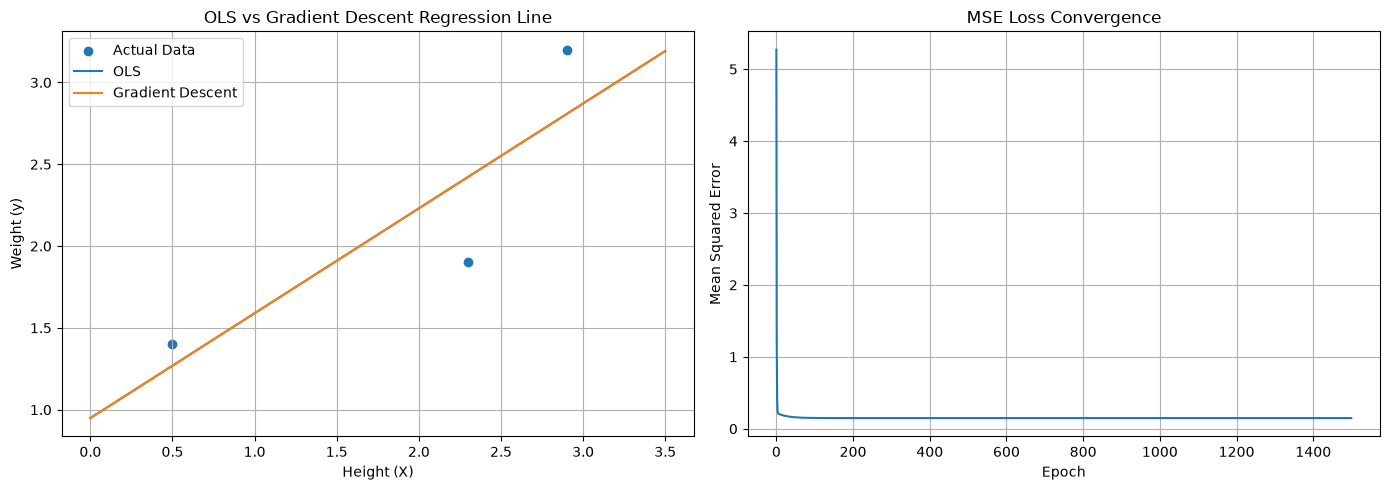

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regression lines
axes[0].scatter(X, y, label="Actual Data")

x_vals = np.linspace(0, 3.5, 100)

axes[0].plot(
    x_vals,
    m_ols * x_vals + c_ols,
    label="OLS"
)

axes[0].plot(
    x_vals,
    m_gd * x_vals + c_gd,
    label="Gradient Descent"
)

axes[0].set_title("OLS vs Gradient Descent Regression Line")
axes[0].set_xlabel("Height (X)")
axes[0].set_ylabel("Weight (y)")
axes[0].legend()
axes[0].grid(True)


# Loss curve
axes[1].plot(losses)

axes[1].set_title("MSE Loss Convergence")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mean Squared Error")
axes[1].grid(True)

plt.tight_layout()
plt.show()